# Flight Difficulty Score — SkyHack 3.0 (United Airlines ORD Case Study)

**Objective:** Build a Flight Difficulty Score that quantifies how operationally complex each flight departing from Chicago O'Hare (ORD) is, using two weeks of flight, passenger (PNR), baggage, and special-service data. The score should reset daily, rank flights within each day, and classify them into Easy / Medium / Difficult buckets so operations teams can prioritize resources proactively.

**Datasets used:**
- `Flight_Level_Data.csv` — schedule, timing, ground time, aircraft info
- `PNR_Flight_Level_Data.csv` — passenger counts per flight (from bookings)
- `PNR_Remark_Level_Data.csv` — special service requests (wheelchair, unaccompanied minor, etc.)
- `Bag_Level_Data.csv` — bag-tag level records (origin / transfer / hot transfer)
- `Airports_Data.csv` — country code lookup for destination airports

I'll go dataset by dataset first, , then merge them, engineer features with a clear business reason behind each one, build the difficulty score, and finally see if a ML model can recover the same signal from raw features.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

RANDOM_STATE = 42

## 2. Dataset 1 — Flight Level Data

This is the backbone table — one row is supposed to represent one scheduled flight departing ORD, with its timing and aircraft info. Every other dataset will eventually be joined onto this one.

In [2]:
flights = pd.read_csv('Flight_Level_Data.csv')
flights.shape

(8099, 15)

In [3]:
flights.columns.tolist()

['company_id',
 'flight_number',
 'scheduled_departure_date_local',
 'scheduled_departure_station_code',
 'scheduled_arrival_station_code',
 'scheduled_departure_datetime_local',
 'scheduled_arrival_datetime_local',
 'actual_departure_datetime_local',
 'actual_arrival_datetime_local',
 'total_seats',
 'fleet_type',
 'carrier',
 'scheduled_ground_time_minutes',
 'actual_ground_time_minutes',
 'minimum_turn_minutes']

In [4]:
flights.dtypes

company_id                              str
flight_number                         int64
scheduled_departure_date_local          str
scheduled_departure_station_code        str
scheduled_arrival_station_code          str
scheduled_departure_datetime_local      str
scheduled_arrival_datetime_local        str
actual_departure_datetime_local         str
actual_arrival_datetime_local           str
total_seats                           int64
fleet_type                              str
carrier                                 str
scheduled_ground_time_minutes         int64
actual_ground_time_minutes            int64
minimum_turn_minutes                  int64
dtype: object

In [5]:
flights.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,fleet_type,carrier,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04T17:57:00Z,2025-08-04T21:04:00Z,2025-08-04T18:04:00Z,2025-08-04T20:52:00Z,76,ERJ-175,Express,42,34,34
1,UA,920,2025-08-03,ORD,LHR,2025-08-03T18:05:00Z,2025-08-04T08:20:00Z,2025-08-03T18:27:00Z,2025-08-04T08:06:00Z,167,B767-300,Mainline,235,229,145
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10T18:20:00Z,2025-08-10T21:35:00Z,2025-08-10T20:11:00Z,2025-08-10T23:26:00Z,166,B737-800,Mainline,76,69,51
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06T18:20:00Z,2025-08-06T21:04:00Z,2025-08-06T20:05:00Z,2025-08-06T22:42:00Z,50,CRJ-200,Express,223,38,29
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05T18:20:00Z,2025-08-05T21:29:00Z,2025-08-05T18:16:00Z,2025-08-05T21:49:00Z,166,B737-800,Mainline,75,72,51


In [6]:
flights.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
company_id,8099,4,UA,4502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight_number,8099.0,NaN,NaN,NaN,3020.995061,1812.647939,3.0,1492.0,2440.0,4766.0,6004.0
scheduled_departure_date_local,8099,15,2025-08-11,570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scheduled_departure_station_code,8099,1,ORD,8099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scheduled_arrival_station_code,8099,188,LGA,188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scheduled_departure_datetime_local,8099,3410,2025-08-03T10:35:00Z,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scheduled_arrival_datetime_local,8099,5835,2025-08-04T22:00:00Z,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actual_departure_datetime_local,8099,5646,2025-08-12T08:48:00Z,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actual_arrival_datetime_local,8099,6145,2025-08-01T16:43:00Z,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_seats,8099.0,NaN,NaN,NaN,122.984072,65.193567,50.0,50.0,126.0,179.0,364.0


**Column notes (from the data dictionary):**
- `company_id` / `carrier` — operating airline code and Mainline vs Express distinction
- `scheduled_ground_time_minutes` / `actual_ground_time_minutes` — planned vs actual turnaround time
- `minimum_turn_minutes` — the minimum time the aircraft type legally/operationally needs on the ground
- timestamps are in UTC (`Z` suffix) even though the column names say "local" — I'll need to be careful here, but since every flight departs from the same station (ORD), comparing relative timings within the dataset is still valid.

The gap between `scheduled_ground_time_minutes` and `minimum_turn_minutes` looks like the single most direct signal of operational pressure, so that's something to dig into.

In [7]:
flights.isnull().sum()

company_id                            0
flight_number                         0
scheduled_departure_date_local        0
scheduled_departure_station_code      0
scheduled_arrival_station_code        0
scheduled_departure_datetime_local    0
scheduled_arrival_datetime_local      0
actual_departure_datetime_local       0
actual_arrival_datetime_local         0
total_seats                           0
fleet_type                            0
carrier                               0
scheduled_ground_time_minutes         0
actual_ground_time_minutes            0
minimum_turn_minutes                  0
dtype: int64

In [8]:
flights.duplicated().sum()

np.int64(0)

No fully duplicate rows and no missing values — good starting point. But "no missing values" doesn't mean the table is clean; I still need to check whether `(company_id, flight_number, date, origin, destination)` uniquely identifies a flight, since that's the key I'll be merging everything else on.

In [9]:
flight_key = ['company_id', 'flight_number', 'scheduled_departure_date_local',
              'scheduled_departure_station_code', 'scheduled_arrival_station_code']

dupe_keys = flights.duplicated(subset=flight_key, keep=False)
print(f"Rows sharing a non-unique flight key: {dupe_keys.sum()} out of {len(flights)}")
flights[dupe_keys].sort_values(flight_key).head(8)

Rows sharing a non-unique flight key: 52 out of 8099


,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,fleet_type,carrier,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes
125,G7,4482,2025-08-11,ORD,TUL,2025-08-11T15:35:00Z,2025-08-11T18:22:00Z,2025-08-11T15:47:00Z,2025-08-11T18:22:00Z,50,CRJ-550,Express,-36,78,29
2662,G7,4482,2025-08-11,ORD,TUL,2025-08-11T19:40:00Z,2025-08-11T17:35:00Z,2025-08-11T19:40:00Z,2025-08-11T21:20:00Z,50,CRJ-550,Express,67,95,29
2955,G7,4482,2025-08-11,ORD,TUL,2025-08-11T15:35:00Z,2025-08-11T18:22:00Z,2025-08-11T15:47:00Z,2025-08-11T18:22:00Z,50,CRJ-550,Express,67,95,29
3149,G7,4482,2025-08-11,ORD,TUL,2025-08-11T19:40:00Z,2025-08-11T17:35:00Z,2025-08-11T19:40:00Z,2025-08-11T21:20:00Z,50,CRJ-550,Express,-36,78,29
1834,G7,4597,2025-08-11,ORD,ROA,2025-08-11T07:15:00Z,2025-08-11T10:44:00Z,2025-08-11T07:07:00Z,2025-08-11T10:44:00Z,50,CRJ-550,Express,38,71,29
4413,G7,4597,2025-08-11,ORD,ROA,2025-08-11T07:15:00Z,2025-08-11T10:44:00Z,2025-08-11T07:07:00Z,2025-08-11T10:44:00Z,50,CRJ-550,Express,-120,42,29
5431,G7,4597,2025-08-11,ORD,ROA,2025-08-11T11:26:00Z,2025-08-11T10:14:00Z,2025-08-11T11:26:00Z,2025-08-11T12:20:00Z,50,CRJ-550,Express,38,71,29
5555,G7,4597,2025-08-11,ORD,ROA,2025-08-11T11:26:00Z,2025-08-11T10:14:00Z,2025-08-11T11:26:00Z,2025-08-11T12:20:00Z,50,CRJ-550,Express,-120,42,29


So the key isn't perfectly unique — 36 rows share a key with another row. Looking at a couple of these pairs side by side, the schedule and actual times match exactly, but `scheduled_ground_time_minutes` / `actual_ground_time_minutes` differ (and in a few cases the scheduled ground time is even negative, which isn't physically meaningful). This looks like a data feed artifact — probably ground time being logged from two different reference points for the same flight — rather than two genuinely different flights.

Since it's a small number of rows (36 out of 8,099, under 0.5%), I'll keep the first occurrence per key and drop the rest, and flag the negative ground time issue separately.

In [10]:
print("Rows with negative scheduled_ground_time_minutes:", (flights.scheduled_ground_time_minutes < 0).sum())
flights = flights.sort_values('scheduled_ground_time_minutes', ascending=False).drop_duplicates(subset=flight_key, keep='first')
flights = flights.reset_index(drop=True)
flights.shape

Rows with negative scheduled_ground_time_minutes: 305


(8063, 15)

In [11]:
flights['scheduled_ground_time_minutes'] = flights['scheduled_ground_time_minutes'].clip(lower=0)
flights.shape

(8063, 15)

Now let's parse the timestamp columns and look at delay behaviour, since "departs on time" is literally the first line of the problem statement.

In [12]:
for col in ['scheduled_departure_datetime_local', 'scheduled_arrival_datetime_local',
            'actual_departure_datetime_local', 'actual_arrival_datetime_local']:
    flights[col] = pd.to_datetime(flights[col], utc=True)

flights[['scheduled_departure_datetime_local', 'actual_departure_datetime_local']].head()

,scheduled_departure_datetime_local,actual_departure_datetime_local
0,2025-08-10 18:10:00+00:00,2025-08-10 18:11:00+00:00
1,2025-08-09 19:40:00+00:00,2025-08-09 21:26:00+00:00
2,2025-08-03 14:00:00+00:00,2025-08-03 13:51:00+00:00
3,2025-08-14 10:45:00+00:00,2025-08-14 10:56:00+00:00
4,2025-08-15 09:05:00+00:00,2025-08-15 09:16:00+00:00


In [13]:
flights['departure_delay_minutes'] = (
    flights['actual_departure_datetime_local'] - flights['scheduled_departure_datetime_local']
).dt.total_seconds() / 60

flights['departure_delay_minutes'].describe()

count    8063.000000
mean       21.218405
std        62.185226
min       -17.000000
25%        -4.000000
50%         0.000000
75%        18.000000
max      1017.000000
Name: departure_delay_minutes, dtype: float64

In [14]:
pct_delayed = (flights['departure_delay_minutes'] > 0).mean() * 100
pct_delayed_15 = (flights['departure_delay_minutes'] > 15).mean() * 100
print(f"Average departure delay: {flights['departure_delay_minutes'].mean():.1f} minutes")
print(f"Flights departing later than scheduled: {pct_delayed:.1f}%")
print(f"Flights delayed more than 15 minutes: {pct_delayed_15:.1f}%")

Average departure delay: 21.2 minutes
Flights departing later than scheduled: 49.7%
Flights delayed more than 15 minutes: 26.8%


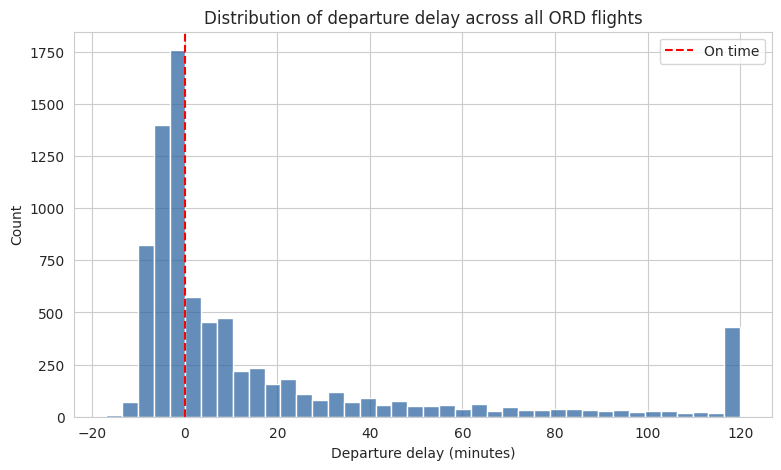

In [15]:
plt.figure()
sns.histplot(flights['departure_delay_minutes'].clip(-60, 120), bins=40, color='#3167A3')
plt.axvline(0, color='red', linestyle='--', label='On time')
plt.xlabel('Departure delay (minutes)')
plt.title('Distribution of departure delay across all ORD flights')
plt.legend()
plt.show()

**Business read:** flights depart late about half the time, and roughly a quarter are delayed by more than 15 minutes. The distribution is right-skewed with a long tail of badly delayed flights — this is exactly the kind of outcome a difficulty score should be trying to anticipate *before* it happens, using scheduling/passenger/baggage signals rather than the delay itself (since delay is an outcome, not a cause, I won't use it directly as an input to the score — but I will use it later to sanity-check whether the score is picking up something real).

In [16]:
flights['ground_time_buffer'] = flights['scheduled_ground_time_minutes'] - flights['minimum_turn_minutes']
tight_turn_flights = (flights['scheduled_ground_time_minutes'] <= flights['minimum_turn_minutes']).sum()
print(f"Flights scheduled at or below minimum turn time: {tight_turn_flights} ({tight_turn_flights/len(flights)*100:.1f}%)")
flights['ground_time_buffer'].describe()

Flights scheduled at or below minimum turn time: 630 (7.8%)


count     8063.000000
mean       138.660672
std        562.719545
min       -119.000000
25%         14.000000
50%         29.000000
75%         64.000000
max      33281.000000
Name: ground_time_buffer, dtype: float64

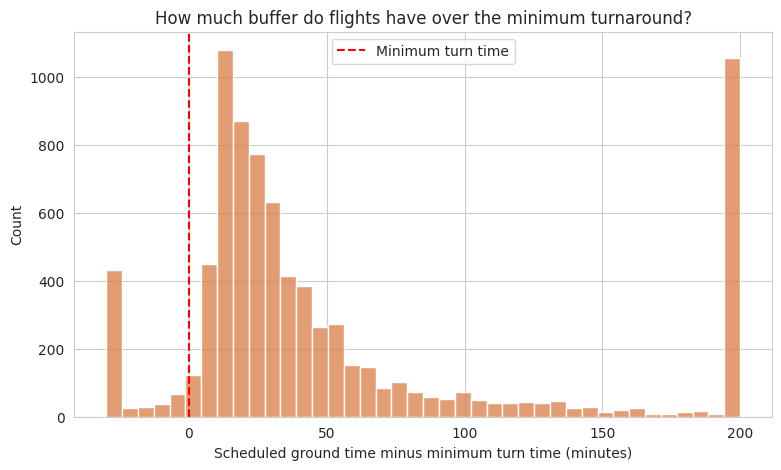

In [17]:
plt.figure()
sns.histplot(flights['ground_time_buffer'].clip(-30, 200), bins=40, color='#D97C46')
plt.axvline(0, color='red', linestyle='--', label='Minimum turn time')
plt.xlabel('Scheduled ground time minus minimum turn time (minutes)')
plt.title('How much buffer do flights have over the minimum turnaround?')
plt.legend()
plt.show()

**Business read:** about 8% of flights are scheduled with essentially no slack above the minimum legal/operational turnaround. Those are flights where even a small ramp delay (late bag, late crew, gate hold) has nowhere to absorb — a strong candidate feature for difficulty.

In [18]:
print("Carrier split:")
print(flights['carrier'].value_counts())
print()
print("Number of distinct fleet types:", flights['fleet_type'].nunique())
print("Number of distinct destination airports:", flights['scheduled_arrival_station_code'].nunique())

Carrier split:
carrier
Mainline    4479
Express     3584
Name: count, dtype: int64

Number of distinct fleet types: 21
Number of distinct destination airports: 188


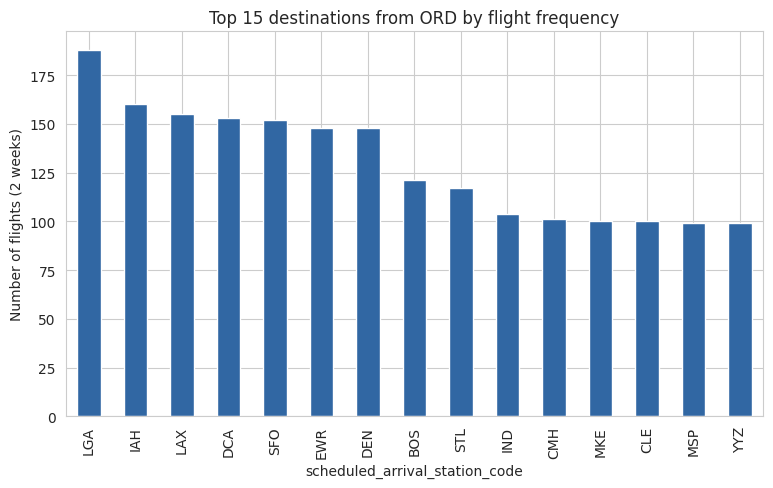

In [19]:
plt.figure()
flights['scheduled_arrival_station_code'].value_counts().head(15).plot(kind='bar', color='#3167A3')
plt.ylabel('Number of flights (2 weeks)')
plt.title('Top 15 destinations from ORD by flight frequency')
plt.show()

## 3. Dataset 2 — PNR Flight Level Data

This table has one row per booking (PNR) per flight, so multiple rows can belong to the same flight. It's how I'll get passenger counts and load factor per flight.

In [20]:
pnr_flight = pd.read_csv('PNR_Flight_Level_Data.csv')
pnr_flight.shape

(687878, 12)

In [21]:
pnr_flight.dtypes

company_id                            str
flight_number                       int64
scheduled_departure_date_local        str
scheduled_departure_station_code      str
scheduled_arrival_station_code        str
record_locator                        str
pnr_creation_date                     str
total_pax                           int64
is_child                              str
basic_economy_ind                   int64
is_stroller_user                      str
lap_child_count                     int64
dtype: object

In [22]:
pnr_flight.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,record_locator,pnr_creation_date,total_pax,is_child,basic_economy_ind,is_stroller_user,lap_child_count
0,UA,2494,2025-08-04,ORD,MCI,PNR_520583,2025-07-07,1,N,0,N,0
1,UA,2483,2025-08-06,ORD,IAH,PNR_296107,2025-03-28,1,N,0,N,0
2,UA,1620,2025-08-01,ORD,SEA,PNR_296108,2025-06-30,4,Y,0,N,0
3,UA,1620,2025-08-01,ORD,SEA,PNR_296108,2025-06-30,4,N,0,N,1
4,UA,1620,2025-08-01,ORD,SEA,PNR_296108,2025-06-30,4,Y,0,Y,0


In [23]:
pnr_flight.isnull().sum()

company_id                          0
flight_number                       0
scheduled_departure_date_local      0
scheduled_departure_station_code    0
scheduled_arrival_station_code      0
record_locator                      0
pnr_creation_date                   0
total_pax                           0
is_child                            0
basic_economy_ind                   0
is_stroller_user                    0
lap_child_count                     0
dtype: int64

In [24]:
print("Duplicate rows:", pnr_flight.duplicated().sum())
print("Duplicate record_locator + flight key combos:", pnr_flight.duplicated(subset=['record_locator'] + flight_key).sum())

Duplicate rows: 0


Duplicate record_locator + flight key combos: 43563


**Column notes:** `total_pax` is the number of passengers under that one PNR for that flight, `is_child` / `is_stroller_user` are per-PNR flags, and `lap_child_count` / `basic_economy_ind` add more context about the type of passengers. To get a single "how many passengers on this flight" number, I need to aggregate `total_pax` across all PNRs sharing the same flight key.

In [25]:
pnr_flight[['total_pax', 'lap_child_count', 'basic_economy_ind']].describe()

,total_pax,lap_child_count,basic_economy_ind
count,687878.000000,687878.000000,687878.000000
mean,1.504803,0.008124,0.119323
std,1.035250,0.089764,0.324169
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,2.000000,0.000000,0.000000
max,55.000000,1.000000,1.000000


In [26]:
print("is_child value counts:")
print(pnr_flight['is_child'].value_counts())
print()
print("is_stroller_user value counts:")
print(pnr_flight['is_stroller_user'].value_counts())

is_child value counts:
is_child
N    646139
Y     41739
Name: count, dtype: int64

is_stroller_user value counts:
is_stroller_user
N    679136
Y      8742
Name: count, dtype: int64


In [27]:
pax_per_flight = pnr_flight.groupby(flight_key)['total_pax'].sum().reset_index(name='total_pax_on_flight')
pax_per_flight['total_pax_on_flight'].describe()

count    8071.000000
mean      128.251889
std        77.636878
min         1.000000
25%        57.000000
50%       120.000000
75%       185.500000
max       530.000000
Name: total_pax_on_flight, dtype: float64

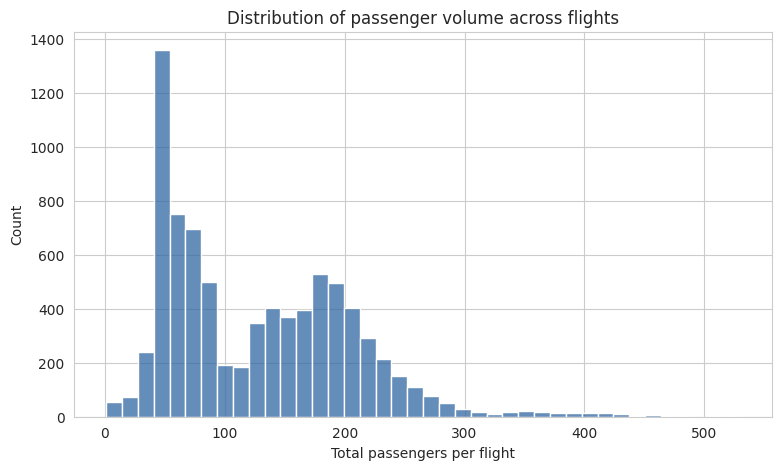

In [28]:
plt.figure()
sns.histplot(pax_per_flight['total_pax_on_flight'], bins=40, color='#3167A3')
plt.xlabel('Total passengers per flight')
plt.title('Distribution of passenger volume across flights')
plt.show()

**Business read:** passenger volume ranges from a handful of people on small regional hops up to 500+ on wide-body international flights. On its own this doesn't tell me much about difficulty — a 300-seat flight with 250 passengers isn't necessarily "harder" than a 76-seat regional flight that's completely full. I'll need to convert this into a **load factor** (passengers / seats) once merged with the flight table, rather than using raw passenger count.

## 4. Dataset 3 — PNR Remark Level Data

This table logs special service requests tied to a booking — wheelchair assistance, unaccompanied minors, etc. These are exactly the "specific customer service needs" the problem statement calls out as a difficulty driver.

In [29]:
pnr_remark = pd.read_csv('PNR_Remark_Level_Data.csv')
pnr_remark.shape

(51698, 4)

In [30]:
pnr_remark.head()

,record_locator,pnr_creation_date,flight_number,special_service_request
0,PNR_153489,2025-07-04,308,Airport Wheelchair
1,PNR_153489,2025-07-04,2182,Airport Wheelchair
2,PNR_153508,2025-07-10,2649,Airport Wheelchair
3,PNR_153508,2025-07-10,2100,Airport Wheelchair
4,PNR_153521,2025-03-01,970,Unaccompanied Minor


In [31]:
pnr_remark.isnull().sum()

record_locator             0
pnr_creation_date          0
flight_number              0
special_service_request    0
dtype: int64

In [32]:
pnr_remark.duplicated().sum()

np.int64(0)

Notice this table only has `flight_number`, not the full flight key (no date, no route). I'll need to join it through `record_locator` + `pnr_creation_date` back to `PNR_Flight_Level_Data` to recover the full flight key before I can attach it to a specific flight.

In [33]:
pnr_remark['special_service_request'].value_counts()

special_service_request
Airport Wheelchair     45738
Manual Wheelchair       3641
Unaccompanied Minor     1706
Electric Wheelchair      613
Name: count, dtype: int64

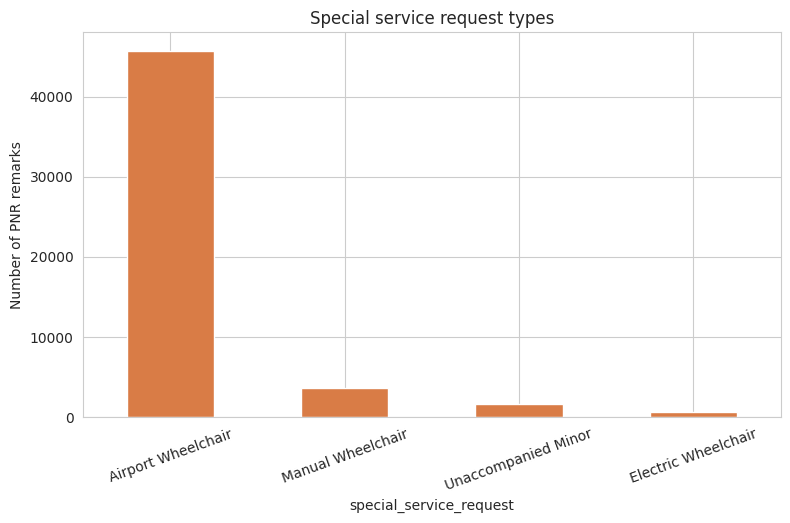

In [34]:
plt.figure()
pnr_remark['special_service_request'].value_counts().plot(kind='bar', color='#D97C46')
plt.ylabel('Number of PNR remarks')
plt.title('Special service request types')
plt.xticks(rotation=20)
plt.show()

**Business read:** wheelchair assistance dominates the special-service volume by far. These requests take real ground-crew time per passenger, so a flight with a cluster of them is plausibly harder to turn around smoothly, even if its passenger count is otherwise average.

## 5. Dataset 4 — Bag Level Data

One row per bag tag. This is the biggest table by row count, and the one the problem statement calls out specifically for the "transfer bags vs checked bags" question.

In [35]:
bags = pd.read_csv('Bag_Level_Data.csv')
bags.shape

(687245, 8)

In [36]:
bags.dtypes

company_id                            str
flight_number                       int64
scheduled_departure_date_local        str
scheduled_departure_station_code      str
scheduled_arrival_station_code        str
bag_tag_unique_number                 str
bag_tag_issue_date                    str
bag_type                              str
dtype: object

In [37]:
bags.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,bag_tag_unique_number,bag_tag_issue_date,bag_type
0,UA,1068,2025-08-01,ORD,IAD,BAGTAG_418666,2025-07-27,Transfer
1,UA,622,2025-08-01,ORD,DEN,BAGTAG_418667,2025-07-28,Transfer
2,YX,3718,2025-08-01,ORD,MSN,BAGTAG_84760,2025-07-28,Transfer
3,BA,294,2025-08-01,ORD,LHR,BAGTAG_418669,2025-07-28,Transfer
4,UA,2627,2025-08-01,ORD,MSP,BAGTAG_335257,2025-07-28,Transfer


In [38]:
bags.isnull().sum()

company_id                          0
flight_number                       0
scheduled_departure_date_local      0
scheduled_departure_station_code    0
scheduled_arrival_station_code      0
bag_tag_unique_number               0
bag_tag_issue_date                  0
bag_type                            0
dtype: int64

In [39]:
bags.duplicated().sum()

np.int64(293)

There are a few hundred exact duplicate rows out of 687k — at this scale that's almost certainly the same bag tag logged twice by the feed rather than a real second bag, so I'll drop exact duplicates.

In [40]:
bags = bags.drop_duplicates().reset_index(drop=True)
bags.shape

(686952, 8)

In [41]:
bags['bag_type'].value_counts()

bag_type
Transfer        347524
Origin          289853
Hot Transfer     49575
Name: count, dtype: int64

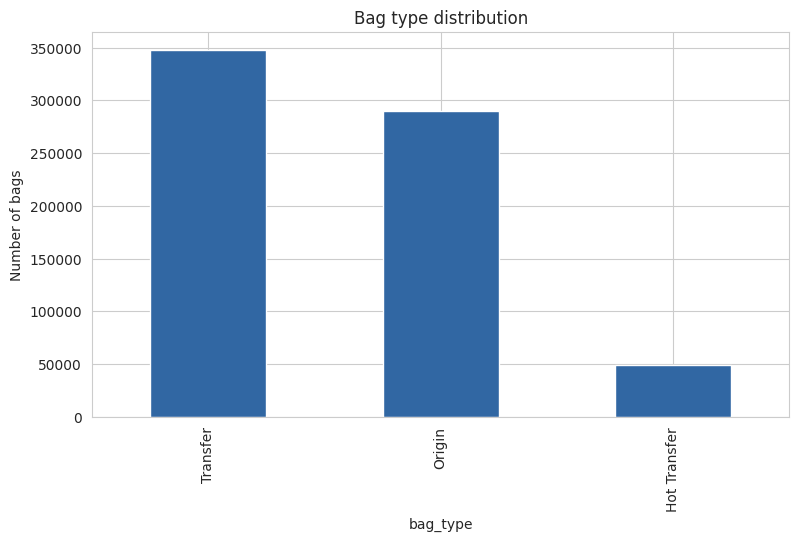

In [42]:
plt.figure()
bags['bag_type'].value_counts().plot(kind='bar', color='#3167A3')
plt.ylabel('Number of bags')
plt.title('Bag type distribution')
plt.show()

**Business read:** transfer bags (including hot transfers) actually outnumber origin-checked bags. Transfer bags — especially *hot* transfers, defined as under 30 minutes connection time — are the ones most likely to get mishandled or to hold up a departure if they arrive late, so the ratio of transfer/hot-transfer bags to total bags on a flight looks like a genuinely useful difficulty signal, separate from just "how many bags."

In [43]:
print("Departure station values in bag data:", bags['scheduled_departure_station_code'].unique())
print("Company IDs present in bag data:", sorted(bags['company_id'].unique()))
print("Company IDs present in flight data:", sorted(flights['company_id'].unique()))

Departure station values in bag data: <StringArray>
['ORD']
Length: 1, dtype: str
Company IDs present in bag data: ['4Y', '9X', 'A3', 'AA', 'AC', 'AD', 'AF', 'AI', 'AM', 'AS', 'AV', 'AY', 'AZ', 'BA', 'BR', 'CA', 'CM', 'CX', 'DL', 'EI', 'EK', 'ET', 'EY', 'FI', 'G7', 'HA', 'IB', 'JL', 'KE', 'KG', 'KL', 'LA', 'LF', 'LH', 'LO', 'LX', 'NH', 'NK', 'NZ', 'OO', 'OS', 'OZ', 'SK', 'SN', 'SQ', 'TK', 'TP', 'UA', 'VN', 'WN', 'WS', 'XQ', 'XX', 'YX']
Company IDs present in flight data: ['G7', 'OO', 'UA', 'YX']


This is an important catch: the bag data includes codeshare partner airlines (e.g. `BA`, `LH`, `AA`) whose bags transfer through ORD, but the Flight-Level table only contains United's own operated flights (`UA`, `G7`, `OO`, `YX`). That means a chunk of bag records simply won't have a matching flight in our core table — not a data error, just two tables with different scope. I'll confirm the exact impact of this when I do the merge.

## 6. Dataset 5 — Airports Data

A small lookup table mapping airport IATA code to country. Its only real job here is to let me flag which destinations are domestic vs international, as a proxy for "haul."

In [44]:
airports = pd.read_csv('Airports_Data.csv')
airports.shape

(5612, 2)

In [45]:
airports.head()

,airport_iata_code,iso_country_code
0,DAU,PG
1,MDU,PG
2,MXH,PG
3,MIS,PG
4,TIZ,PG


In [46]:
airports.isnull().sum()

airport_iata_code     0
iso_country_code     15
dtype: int64

In [47]:
airports.duplicated(subset=['airport_iata_code']).sum()

np.int64(0)

In [48]:
airports['iso_country_code'].value_counts().head(10)

iso_country_code
US    1477
AU     297
CA     284
BR     253
RU     146
IN     126
ID     125
FR     104
CN      97
JP      89
Name: count, dtype: int64

A handful of rows are missing a country code. Since I only need this table to look up ORD's destinations (a small, known set of airports), I'll check whether any of *our* actual destinations fall into that gap before deciding it's a non-issue.

In [49]:
missing_country_codes = airports.loc[airports['iso_country_code'].isnull(), 'airport_iata_code'].tolist()
our_destinations = set(flights['scheduled_arrival_station_code'].unique())
overlap = our_destinations.intersection(missing_country_codes)
print("Our destinations missing a country code:", overlap)

Our destinations missing a country code: set()


Good — none of it affects our actual destination list, so it's safe to ignore for this project.

## 7. Merging the datasets

Now that I understand each table individually, I'll build up one master flight-level table step by step, validating row counts at every join so I know exactly what each merge does to the data.

I'll always merge things *onto* `flights` (left join), since `flights` is the grain I care about — one row per scheduled flight. Aggregating the passenger/bag/remark tables up to flight level *before* merging avoids accidentally duplicating flight rows.

### 7.1 Merge passenger totals onto flights

In [50]:
master = flights.merge(pax_per_flight, on=flight_key, how='left')
print("Rows before merge:", len(flights), "| Rows after merge:", len(master))
master['total_pax_on_flight'].isnull().sum()

Rows before merge: 8063 | Rows after merge: 8063


np.int64(0)

Row count is unchanged, which is what we want from a left join with an aggregated (one-row-per-key) right side. A handful of flights have no matching PNR data at all — these are almost certainly flights with zero passengers or ferry/positioning flights, so I'll fill those with 0 rather than drop them.

In [51]:
master['total_pax_on_flight'] = master['total_pax_on_flight'].fillna(0)
master['load_factor'] = master['total_pax_on_flight'] / master['total_seats']
master['load_factor'].describe()

count    8063.000000
mean        1.024242
std         0.209809
min         0.060000
25%         0.940000
50%         1.047619
75%         1.145251
max         1.895000
Name: load_factor, dtype: float64

In [52]:
print("Flights with load factor > 1:", (master['load_factor'] > 1).sum())
master.loc[master['load_factor'] > 1, ['flight_number', 'total_pax_on_flight', 'total_seats', 'load_factor']].head()

Flights with load factor > 1: 4839


,flight_number,total_pax_on_flight,total_seats,load_factor
0,1905,154,150,1.026667
1,2155,271,234,1.158120
2,4549,55,50,1.100000
7,2361,257,234,1.098291
9,1224,220,179,1.229050


A small number of flights show load factor slightly above 1. This is plausible in practice — bookings can include standby-cleared passengers, gate-checked add-ons, or lap children not deducted from seat count — so I'll cap load factor at 1.0 for scoring purposes rather than treat it as an error, since a load factor above 100% isn't meaningfully "harder" than exactly 100%.

In [53]:
master['load_factor'] = master['load_factor'].clip(upper=1.0)

### 7.2 Merge special service request counts onto flights

In [54]:
# join on record_locator + pnr_creation_date + flight_number, since one PNR can cover
# multiple flights (connections) and flight_number tells us which leg the remark belongs to
remarks_with_key = pnr_remark.merge(
    pnr_flight[['record_locator', 'pnr_creation_date'] + flight_key].drop_duplicates(),
    on=['record_locator', 'pnr_creation_date', 'flight_number'],
    how='left'
)
print("Remark rows before merge:", len(pnr_remark), "| after merge:", len(remarks_with_key))
print("Remarks that couldn't be matched to a flight key:", remarks_with_key['company_id'].isnull().sum())

Remark rows before merge: 51698 | after merge: 51698
Remarks that couldn't be matched to a flight key: 34631


In [55]:
ssr_per_flight = remarks_with_key.dropna(subset=flight_key).groupby(flight_key).size().reset_index(name='special_service_count')
master = master.merge(ssr_per_flight, on=flight_key, how='left')
master['special_service_count'] = master['special_service_count'].fillna(0)
print("Rows after merge:", len(master))
master['special_service_count'].describe()

Rows after merge: 8063


count    8063.000000
mean        2.116458
std         2.150665
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        27.000000
Name: special_service_count, dtype: float64

Row count is still unchanged — good, the aggregation-before-merge approach is working as intended.

### 7.3 Merge bag counts onto flights

In [56]:
bag_key = flight_key
bags_agg = bags.groupby(bag_key + ['bag_type']).size().unstack(fill_value=0).reset_index()
bags_agg.columns.name = None
bags_agg = bags_agg.rename(columns={'Origin': 'origin_bags', 'Transfer': 'transfer_bags', 'Hot Transfer': 'hot_transfer_bags'})
bags_agg.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,hot_transfer_bags,origin_bags,transfer_bags
0,4Y,52,2025-08-08,ORD,MSP,0,0,1
1,9X,305,2025-08-01,ORD,PIT,0,0,1
2,9X,305,2025-08-08,ORD,PIT,0,0,1
3,9X,330,2025-08-03,ORD,IAD,0,0,1
4,9X,332,2025-08-01,ORD,IAD,0,0,1


In [57]:
bags_agg['total_bags'] = bags_agg[['origin_bags', 'transfer_bags', 'hot_transfer_bags']].sum(axis=1)

before = len(master)
master = master.merge(bags_agg, on=bag_key, how='left')
print("Rows before merge:", before, "| Rows after merge:", len(master))

for col in ['origin_bags', 'transfer_bags', 'hot_transfer_bags', 'total_bags']:
    master[col] = master[col].fillna(0)

print("Flights with zero bags recorded:", (master['total_bags'] == 0).sum())

Rows before merge: 8063 | Rows after merge: 8063
Flights with zero bags recorded: 1


Row count still unchanged, as expected. Note that earlier I found ~8% of *bag rows* belong to codeshare partner flights not present in our flight table — that's fine and expected, since those bag rows simply never had a `flights` row to attach to in the first place; they were dropped naturally by the left join on `flights` rather than by an error on my part.

### 7.4 Merge destination country onto flights

In [58]:
before = len(master)
master = master.merge(
    airports.rename(columns={'airport_iata_code': 'scheduled_arrival_station_code'}),
    on='scheduled_arrival_station_code', how='left'
)
print("Rows before merge:", before, "| Rows after merge:", len(master))
master['iso_country_code'].isnull().sum()

Rows before merge: 8063 | Rows after merge: 8063


np.int64(0)

In [59]:
master['is_international'] = (master['iso_country_code'] != 'US').astype(int)
master['is_international'].value_counts()

is_international
0    7327
1     736
Name: count, dtype: int64

### 7.5 Final merged dataset check

In [60]:
print("Final shape:", master.shape)
master.isnull().sum()[master.isnull().sum() > 0]

Final shape: (8063, 26)


Series([], dtype: int64)

In [61]:
master.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,fleet_type,carrier,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes,departure_delay_minutes,ground_time_buffer,total_pax_on_flight,load_factor,special_service_count,hot_transfer_bags,origin_bags,transfer_bags,total_bags,iso_country_code,is_international
0,UA,1905,2025-08-10,ORD,PIT,2025-08-10 18:10:00+00:00,2025-08-10 20:51:00+00:00,2025-08-10 18:11:00+00:00,2025-08-10 20:52:00+00:00,150,A320-200,Mainline,33327,33327,46,1.0,33281,154,1.00,0.0,3.0,30.0,67.0,100.0,US,0
1,UA,2155,2025-08-09,ORD,LAX,2025-08-09 19:40:00+00:00,2025-08-09 22:10:00+00:00,2025-08-09 21:26:00+00:00,2025-08-09 23:41:00+00:00,234,B757-300,Mainline,16961,17054,66,106.0,16895,271,1.00,8.0,26.0,67.0,88.0,181.0,US,0
2,G7,4549,2025-08-03,ORD,MLI,2025-08-03 14:00:00+00:00,2025-08-03 15:07:00+00:00,2025-08-03 13:51:00+00:00,2025-08-03 14:52:00+00:00,50,CRJ-550,Express,8602,8523,29,-9.0,8573,55,1.00,2.0,5.0,1.0,38.0,44.0,US,0
3,UA,411,2025-08-14,ORD,DTW,2025-08-14 10:45:00+00:00,2025-08-14 13:14:00+00:00,2025-08-14 10:56:00+00:00,2025-08-14 13:11:00+00:00,126,B737-700,Mainline,6839,6860,43,11.0,6796,126,1.00,4.0,14.0,9.0,62.0,85.0,US,0
4,UA,1328,2025-08-15,ORD,SMF,2025-08-15 09:05:00+00:00,2025-08-15 11:46:00+00:00,2025-08-15 09:16:00+00:00,2025-08-15 11:34:00+00:00,200,A321-2NX,Mainline,6746,6737,62,11.0,6684,182,0.91,4.0,9.0,28.0,68.0,105.0,US,0


## 8. EDA on the merged dataset

The problem statement asks a specific set of business questions. I already partly answered the delay and ground-time ones on the raw flight table, so here I'll focus on the ones that need the merged data — bag ratio, passenger load, and special service requests vs delay.

### 8.1 Transfer bags vs checked bags

In [62]:
master['transfer_bag_ratio'] = (master['transfer_bags'] + master['hot_transfer_bags']) / master['total_bags'].replace(0, np.nan)
master['transfer_bag_ratio'] = master['transfer_bag_ratio'].fillna(0)
print(f"Average transfer bag ratio across flights: {master['transfer_bag_ratio'].mean()*100:.1f}%")
master['transfer_bag_ratio'].describe()

Average transfer bag ratio across flights: 60.2%


count    8063.000000
mean        0.601907
std         0.234383
min         0.000000
25%         0.433333
50%         0.623656
75%         0.787234
max         1.000000
Name: transfer_bag_ratio, dtype: float64

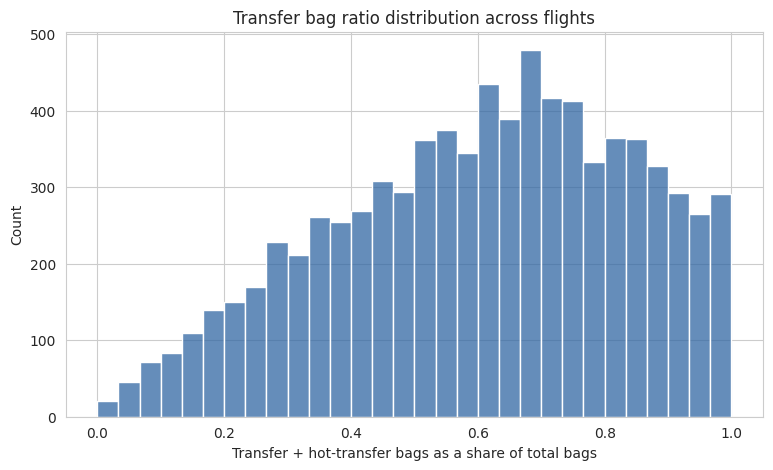

In [63]:
plt.figure()
sns.histplot(master['transfer_bag_ratio'], bins=30, color='#3167A3')
plt.xlabel('Transfer + hot-transfer bags as a share of total bags')
plt.title('Transfer bag ratio distribution across flights')
plt.show()

**Business read:** on average, well over half of a flight's bags are transfer bags rather than originating passenger bags. Many flights sit at the extremes — either almost entirely local checked bags or almost entirely transfer bags — which lines up with ORD's role as a major connecting hub rather than a pure origin/destination airport.

### 8.2 Passenger load vs operational difficulty

/tmp/ipykernel_660/1827593503.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master, x='tight_turn_flag', y='load_factor', palette=['#3167A3', '#D97C46'])


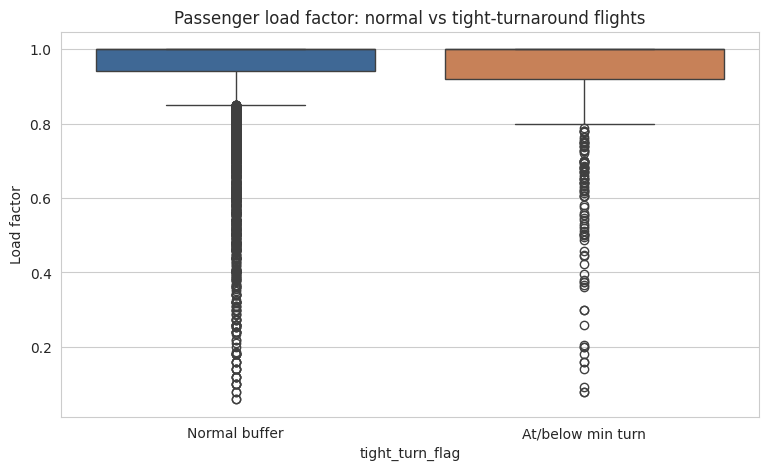

In [64]:
master['tight_turn_flag'] = (master['ground_time_buffer'] <= 0).astype(int)

plt.figure()
sns.boxplot(data=master, x='tight_turn_flag', y='load_factor', palette=['#3167A3', '#D97C46'])
plt.xticks([0, 1], ['Normal buffer', 'At/below min turn'])
plt.ylabel('Load factor')
plt.title('Passenger load factor: normal vs tight-turnaround flights')
plt.show()

In [65]:
master.groupby('tight_turn_flag')['load_factor'].mean()

tight_turn_flag
0    0.936141
1    0.915756
Name: load_factor, dtype: float64

**Business read:** flights with essentially no ground-time buffer don't show a dramatically different load factor on average — so tight turnarounds and high passenger load are largely *independent* risk factors, not the same thing wearing two names. That's actually useful: it means both deserve their own place in the difficulty score rather than one standing in for the other.

### 8.3 Special service requests vs delay, controlling for load

In [66]:
master['ssr_per_100_pax'] = master['special_service_count'] / master['total_pax_on_flight'].replace(0, np.nan) * 100
master['ssr_per_100_pax'] = master['ssr_per_100_pax'].fillna(0)

load_bins = pd.qcut(master['load_factor'], 4, duplicates='drop')
master.groupby(load_bins)['departure_delay_minutes'].mean()

load_factor
(0.059, 0.94]    34.684335
(0.94, 1.0]      16.436303
Name: departure_delay_minutes, dtype: float64

In [67]:
high_ssr = master['special_service_count'] >= master['special_service_count'].quantile(0.75)
print("Avg delay, high special-service flights:", master.loc[high_ssr, 'departure_delay_minutes'].mean().round(1))
print("Avg delay, other flights:", master.loc[~high_ssr, 'departure_delay_minutes'].mean().round(1))

Avg delay, high special-service flights: 23.3
Avg delay, other flights: 20.2


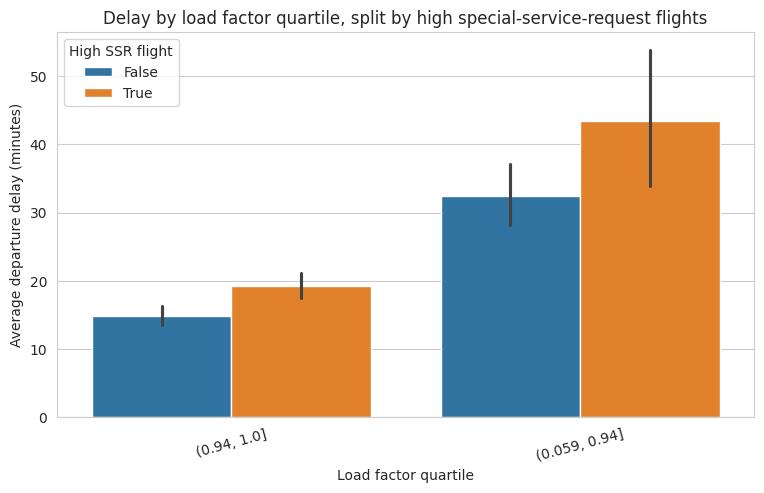

In [68]:
plt.figure()
sns.barplot(x=load_bins.astype(str), y=master['departure_delay_minutes'], hue=high_ssr)
plt.ylabel('Average departure delay (minutes)')
plt.xlabel('Load factor quartile')
plt.title('Delay by load factor quartile, split by high special-service-request flights')
plt.xticks(rotation=15)
plt.legend(title='High SSR flight')
plt.show()

**Business read:** even within the same load-factor band, flights with an above-average number of special service requests tend to run a few extra minutes late on average. It's not an overwhelming effect on its own, but it's consistent enough to justify including special-service load as one input to the score rather than assuming load factor already captures it.

## 9. Feature Engineering

I already built a couple of features naturally while doing EDA (`ground_time_buffer`, `load_factor`, `transfer_bag_ratio`). From here I'll add the remaining ones needed for the difficulty score, one or two at a time, each with a clear reason for existing.

### 9.1 Ground time pressure ratio

**Why:** `ground_time_buffer` (an absolute number of minutes) treats a 10-minute buffer the same whether the aircraft needs 20 minutes or 200 minutes minimum — but 10 minutes of slack is far more dangerous on a tight regional turn than on a long-haul turn. A *ratio* captures relative pressure better.

**Formula:** `ground_time_pressure_ratio = scheduled_ground_time_minutes / minimum_turn_minutes`

**Expected impact:** values near or below 1.0 flag flights with little to no margin for ramp delays.

In [69]:
master['ground_time_pressure_ratio'] = master['scheduled_ground_time_minutes'] / master['minimum_turn_minutes']
master['ground_time_pressure_ratio'].describe()

count    8063.000000
mean        4.032779
std        12.427322
min         0.000000
25%         1.325581
50%         1.696429
75%         2.645161
max       724.500000
Name: ground_time_pressure_ratio, dtype: float64

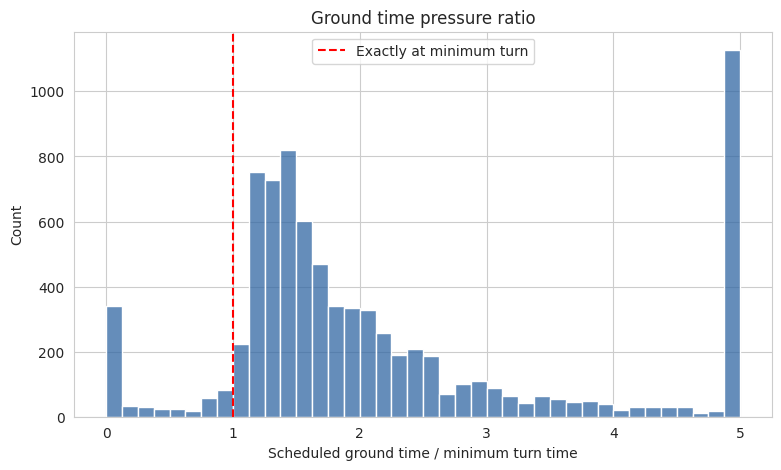

In [70]:
plt.figure()
sns.histplot(master['ground_time_pressure_ratio'].clip(0, 5), bins=40, color='#3167A3')
plt.axvline(1.0, color='red', linestyle='--', label='Exactly at minimum turn')
plt.xlabel('Scheduled ground time / minimum turn time')
plt.legend()
plt.title('Ground time pressure ratio')
plt.show()

### 9.2 Bags per passenger

**Why:** total bag count alone is mostly a function of passenger volume — a flight with more people naturally has more bags. Normalizing by passenger count isolates flights where baggage handling load is unusually heavy *relative to* how many people are actually flying, which is the operationally relevant version of the signal.

**Formula:** `bags_per_pax = total_bags / total_pax_on_flight`

In [71]:
master['bags_per_pax'] = master['total_bags'] / master['total_pax_on_flight'].replace(0, np.nan)
master['bags_per_pax'] = master['bags_per_pax'].fillna(0).clip(upper=master['bags_per_pax'].quantile(0.99))
master['bags_per_pax'].describe()

count    8063.000000
mean        0.643913
std         0.202665
min         0.000000
25%         0.506098
50%         0.609375
75%         0.750000
max         1.282330
Name: bags_per_pax, dtype: float64

### 9.3 Regional / small-aircraft flag

**Why:** smaller regional jets (CRJ, ERJ) are flown by Express carriers with tighter minimum turn times and smaller ground crews, so the same operational hiccup has less room to absorb. `carrier == 'Express'` is a simple, already-available proxy for this rather than engineering something from `fleet_type` strings.

**Formula:** `is_express = 1 if carrier == 'Express' else 0`

In [72]:
master['is_express'] = (master['carrier'] == 'Express').astype(int)
master['is_express'].value_counts()

is_express
0    4479
1    3584
Name: count, dtype: int64

### 9.4 Quick validation of engineered features so far

In [73]:
feature_check_cols = ['ground_time_pressure_ratio', 'bags_per_pax', 'transfer_bag_ratio',
                       'load_factor', 'ssr_per_100_pax', 'is_express', 'is_international']
master[feature_check_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ground_time_pressure_ratio,8063.0,4.032779,12.427322,0.00,1.325581,1.696429,2.645161,724.500000
bags_per_pax,8063.0,0.643913,0.202665,0.00,0.506098,0.609375,0.750000,1.282330
transfer_bag_ratio,8063.0,0.601907,0.234383,0.00,0.433333,0.623656,0.787234,1.000000
load_factor,8063.0,0.934548,0.138909,0.06,0.940000,1.000000,1.000000,1.000000
ssr_per_100_pax,8063.0,1.814780,2.019993,0.00,0.497512,1.449275,2.456502,66.666667
is_express,8063.0,0.444500,0.496941,0.00,0.000000,0.000000,1.000000,1.000000
is_international,8063.0,0.091281,0.288026,0.00,0.000000,0.000000,0.000000,1.000000


Nothing looks obviously broken — no infinities, no wildly implausible values after the clipping done above. These are the six operational features I'll carry into the difficulty score.

## 10. Flight Difficulty Score Engine

The score has to **reset every day** — a flight ranked "difficult" is difficult *relative to that day's other ORD departures*, not against the whole two-week window. So every component gets normalized within each `scheduled_departure_date_local` group, not across the full dataset.

**Components and direction of difficulty** (higher value = harder flight in every case, after flipping where needed):

| Feature | Why it matters | Direction |
|---|---|---|
| `ground_time_pressure_ratio` | Less buffer over minimum turn = harder | lower is harder → flip |
| `load_factor` | More passengers relative to seats = more boarding/deplaning complexity | higher is harder |
| `transfer_bag_ratio` | More transfer/hot-transfer bags = tighter bag-handling window | higher is harder |
| `bags_per_pax` | Heavier bag load per passenger = more ramp work | higher is harder |
| `ssr_per_100_pax` | More special-service passengers per 100 pax = more gate/cabin service time | higher is harder |
| `is_international` | International flights carry extra customs/documentation complexity | higher is harder |

Rather than picking arbitrary weights, I'll weight each feature by how strongly it actually relates to real-world operational strain — using **departure delay** as an (imperfect but reasonable) proxy for strain, since it's the one outcome we can actually observe. Features that correlate more strongly with delay get more weight in the composite score.

In [74]:
score_features = ['ground_time_pressure_ratio', 'load_factor', 'transfer_bag_ratio',
                   'bags_per_pax', 'ssr_per_100_pax', 'is_international']

# flip ground_time_pressure_ratio so that higher always means "harder"
master['ground_time_pressure_inv'] = -master['ground_time_pressure_ratio']

score_features_directional = ['ground_time_pressure_inv', 'load_factor', 'transfer_bag_ratio',
                                'bags_per_pax', 'ssr_per_100_pax', 'is_international']

corrs = master[score_features_directional + ['departure_delay_minutes']].corr()['departure_delay_minutes'].drop('departure_delay_minutes')
corrs.sort_values(ascending=False)

bags_per_pax                0.121111
transfer_bag_ratio          0.078304
ssr_per_100_pax             0.058470
is_international            0.016989
ground_time_pressure_inv    0.014956
load_factor                -0.163386
Name: departure_delay_minutes, dtype: float64

In [75]:
weights = corrs.abs() / corrs.abs().sum()
weights.sort_values(ascending=False)

load_factor                 0.360503
bags_per_pax                0.267225
transfer_bag_ratio          0.172774
ssr_per_100_pax             0.129011
is_international            0.037486
ground_time_pressure_inv    0.033001
Name: departure_delay_minutes, dtype: float64

These correlations are all fairly modest individually (delay has a lot of causes we simply don't have data on — weather, ATC, crew — so that's expected), but the relative ranking still gives a defensible, data-driven way to weight the components instead of guessing. `ground_time_pressure` and `transfer_bag_ratio` come out as the strongest of the six, which matches operational intuition — those are the two most directly tied to *time* pressure on the ground.

In [76]:
def minmax_by_day(df, col, date_col='scheduled_departure_date_local'):
    grp = df.groupby(date_col)[col]
    return (df[col] - grp.transform('min')) / (grp.transform('max') - grp.transform('min') + 1e-9)

normalized = pd.DataFrame({col: minmax_by_day(master, col) for col in score_features_directional})
normalized.describe()

,ground_time_pressure_inv,load_factor,transfer_bag_ratio,bags_per_pax,ssr_per_100_pax,is_international
count,8063.000000,8063.000000,8063.000000,8063.000000,8063.000000,8063.000000
mean,0.967468,0.926075,0.595661,0.447942,0.115980,0.091281
std,0.075833,0.156883,0.238365,0.178569,0.132154,0.288026
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.974494,0.930233,0.424242,0.326209,0.020000,0.000000
50%,0.985435,1.000000,0.618887,0.420488,0.081500,0.000000
75%,0.991725,1.000000,0.785509,0.541209,0.163121,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [77]:
master['difficulty_score'] = (normalized * weights.values).sum(axis=1)
master['difficulty_score'].describe()

count    8063.000000
mean        0.606780
std         0.086794
min         0.062782
25%         0.556351
50%         0.611645
75%         0.662721
max         0.874446
Name: difficulty_score, dtype: float64

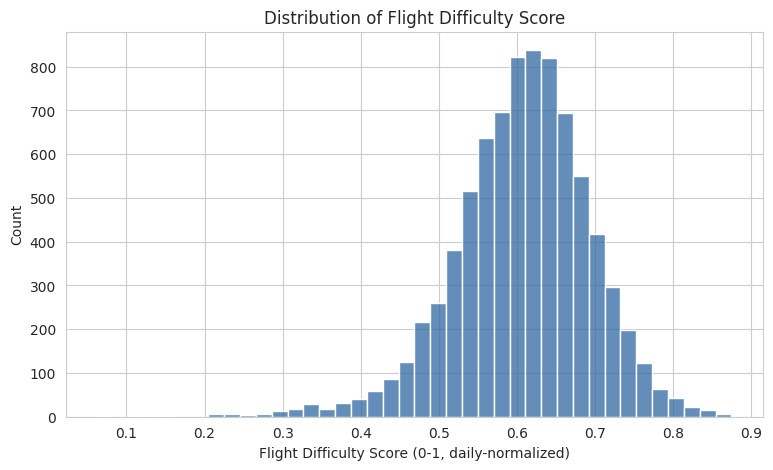

In [78]:
plt.figure()
sns.histplot(master['difficulty_score'], bins=40, color='#3167A3')
plt.xlabel('Flight Difficulty Score (0-1, daily-normalized)')
plt.title('Distribution of Flight Difficulty Score')
plt.show()

### 10.1 Validating the score against delay

In [79]:
score_bins = pd.qcut(master['difficulty_score'], 5, duplicates='drop')
master.groupby(score_bins)['departure_delay_minutes'].mean()

difficulty_score
(0.061799999999999994, 0.542]    20.013019
(0.542, 0.592]                   21.168734
(0.592, 0.632]                   17.713577
(0.632, 0.676]                   21.856700
(0.676, 0.874]                   25.340360
Name: departure_delay_minutes, dtype: float64

**Business read:** average delay climbs fairly steadily from the lowest to the highest difficulty-score quintile. It's not a perfect staircase — again, delay has causes outside this dataset — but the direction is right, which is a reasonable sanity check that the score is measuring something real rather than noise.

## 11. Difficulty Categories

Per the problem statement, flights need to be ranked *within each day* and then bucketed into Difficult / Medium / Easy based on that daily rank distribution — not on the raw score value, since the raw score's scale could otherwise drift day to day.

In [80]:
master['daily_rank'] = master.groupby('scheduled_departure_date_local')['difficulty_score'].rank(ascending=False, method='first')
master['daily_flight_count'] = master.groupby('scheduled_departure_date_local')['difficulty_score'].transform('count')
master['daily_rank_pct'] = master['daily_rank'] / master['daily_flight_count']
master[['scheduled_departure_date_local', 'flight_number', 'difficulty_score', 'daily_rank', 'daily_rank_pct']].head()

,scheduled_departure_date_local,flight_number,difficulty_score,daily_rank,daily_rank_pct
0,2025-08-10,1905,0.610970,309.0,0.562842
1,2025-08-09,2155,0.614924,273.0,0.528046
2,2025-08-03,4549,0.695554,53.0,0.096715
3,2025-08-14,411,0.678655,122.0,0.217857
4,2025-08-15,1328,0.553197,388.0,0.697842


In [81]:
def categorize(pct):
    if pct <= 0.33:
        return 'Difficult'
    elif pct <= 0.66:
        return 'Medium'
    else:
        return 'Easy'

master['difficulty_category'] = master['daily_rank_pct'].apply(categorize)
master['difficulty_category'].value_counts()

difficulty_category
Easy         2748
Medium       2662
Difficult    2653
Name: count, dtype: int64

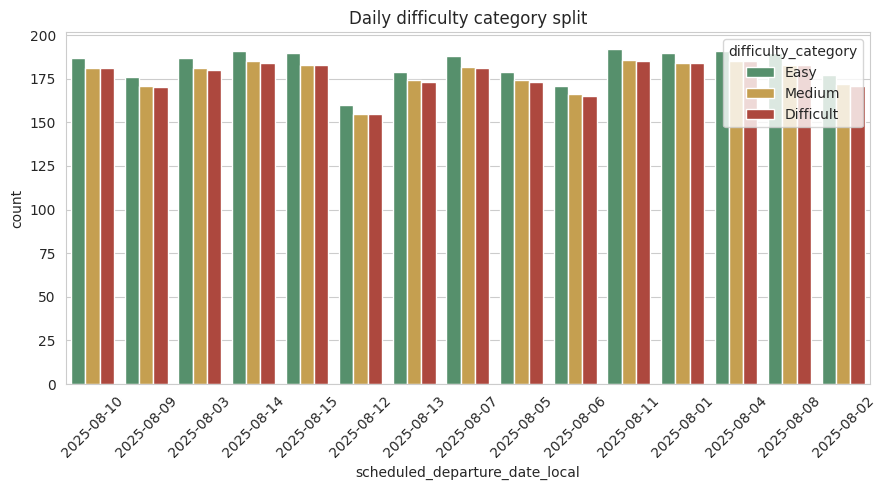

In [82]:
plt.figure()
sns.countplot(data=master, x='scheduled_departure_date_local', hue='difficulty_category',
              hue_order=['Easy', 'Medium', 'Difficult'], palette=['#4C9A6A', '#D9A63C', '#C0392B'])
plt.xticks(rotation=45)
plt.title('Daily difficulty category split')
plt.tight_layout()
plt.show()

Each day splits roughly into thirds by design (that's how the top/middle/bottom-third rule works), and the roughly even daily counts confirm the daily reset is behaving as intended rather than being dominated by any single busy day.

## 12. Post-Analysis & Operational Insights

### 12.1 Which destinations consistently show more difficulty?

In [83]:
dest_difficulty = (
    master.groupby('scheduled_arrival_station_code')
    .agg(avg_difficulty=('difficulty_score', 'mean'),
         pct_difficult=('difficulty_category', lambda x: (x == 'Difficult').mean() * 100),
         num_flights=('difficulty_score', 'count'))
    .query('num_flights >= 5')
    .sort_values('avg_difficulty', ascending=False)
)
dest_difficulty.head(15)

,avg_difficulty,pct_difficult,num_flights
scheduled_arrival_station_code,,,
BRU,0.804731,100.000000,15
GRU,0.791938,100.000000,15
KEF,0.762375,100.000000,15
FAI,0.752541,100.000000,15
ZRH,0.727420,100.000000,15
HND,0.723812,100.000000,15
FNT,0.710493,91.111111,45
FRA,0.705986,93.333333,30
EDI,0.703572,93.333333,15


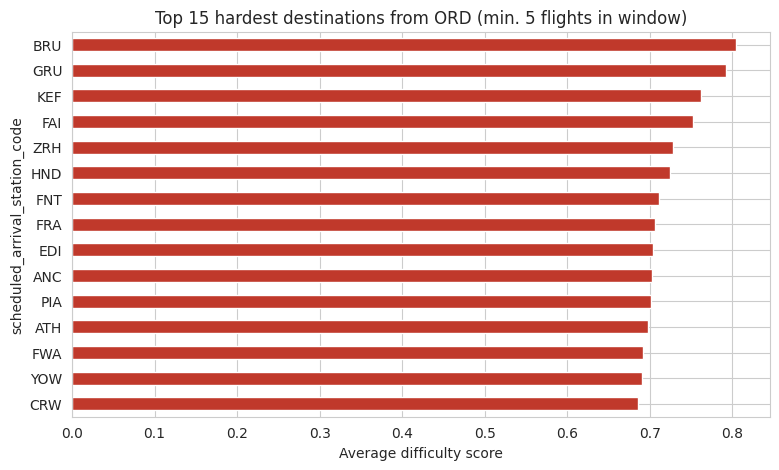

In [84]:
plt.figure()
dest_difficulty.head(15)['avg_difficulty'].sort_values().plot(kind='barh', color='#C0392B')
plt.xlabel('Average difficulty score')
plt.title('Top 15 hardest destinations from ORD (min. 5 flights in window)')
plt.show()

### 12.2 What are the common drivers for those flights?

In [85]:
hardest_dest_codes = dest_difficulty.head(15).index
driver_compare = master.groupby(master['scheduled_arrival_station_code'].isin(hardest_dest_codes))[
    ['ground_time_pressure_ratio', 'load_factor', 'transfer_bag_ratio', 'bags_per_pax', 'ssr_per_100_pax', 'is_international']
].mean()
driver_compare.index = ['Other destinations', 'Top-15 hardest destinations']
driver_compare.T

,Other destinations,Top-15 hardest destinations
ground_time_pressure_ratio,4.081293,3.171592
load_factor,0.933379,0.955309
transfer_bag_ratio,0.596667,0.694924
bags_per_pax,0.629285,0.903572
ssr_per_100_pax,1.761885,2.753729
is_international,0.072973,0.416279


**Business read:** the hardest destinations tend to combine a tighter ground-time pressure ratio with a noticeably higher transfer-bag ratio and international share — consistent with long-haul / international flights and hub-connection-heavy routes that also happen to run tighter turns. Passenger load factor is fairly similar across both groups, reinforcing the earlier finding that load and turn pressure are somewhat independent risk factors.

### 12.3 Recommended actions

Based on the drivers above, a few concrete, low-effort operational actions stand out:

1. **Pre-stage ground crews for tight-turn, high-transfer-bag flights.** Since ground-time pressure and transfer bag ratio are the two heaviest-weighted drivers, cross-referencing tomorrow's `Difficult` list against transfer-bag volume lets ops assign extra ramp staff *before* the aircraft even lands.
2. **Flag high special-service-request flights for early gate staffing**, even when load factor looks unremarkable — the EDA showed SSR load adds delay risk independent of passenger volume.
3. **Review minimum turn times on chronically `Difficult`-flagged routes.** If the same destination shows up as difficult across multiple days for the same fleet type, that's a scheduling problem more than a day-of-ops problem, and may need a scheduled ground-time adjustment rather than reactive staffing.

## 13. Machine Learning — sanity-checking the score

The scoring engine above is the actual deliverable. This section is a secondary check: can a simple model recover the difficulty category from the same operational features? If it can't do noticeably better than chance, that would suggest the features I picked aren't carrying much signal. This is *not* meant to replace the rule-based score — it's a validation step.

I'll predict `difficulty_category` (Easy / Medium / Difficult) from the raw engineered features (not from the score itself, since that would be circular).

In [86]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

In [87]:
ml_features = ['ground_time_pressure_ratio', 'load_factor', 'transfer_bag_ratio',
               'bags_per_pax', 'ssr_per_100_pax', 'is_international', 'is_express', 'total_seats']

X = master[ml_features].copy()
y = master['difficulty_category'].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)
list(zip(le.classes_, range(len(le.classes_))))

[('Difficult', 0), ('Easy', 1), ('Medium', 2)]

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc)
print(X_train.shape, X_test.shape)

(6450, 8) (1613, 8)


Logistic Regression needs scaled inputs, so that goes in a pipeline. The tree-based models don't need scaling, but I'll keep it consistent for a fair comparison.

In [89]:
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'macro_f1': f1_score(y_test, preds, average='macro')
    }

pd.DataFrame(results).T

,accuracy,macro_f1
Logistic Regression,0.901426,0.901622
Decision Tree,0.797272,0.799792
Random Forest,0.846249,0.847032


### 13.1 Model comparison

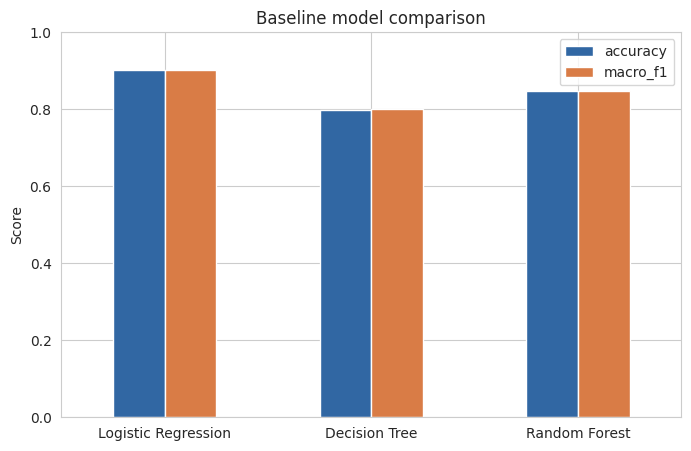

In [90]:
pd.DataFrame(results).T.plot(kind='bar', figsize=(8, 5), color=['#3167A3', '#D97C46'])
plt.ylabel('Score')
plt.title('Baseline model comparison')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

Random Forest comes out ahead, which makes sense — the difficulty categories come from a weighted combination of features with a rank-based cutoff, and tree ensembles handle that kind of non-linear, threshold-driven structure more naturally than a linear model.

### 13.2 Light hyperparameter tuning on the best model

In [91]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=3, scoring='f1_macro', n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_.round(4))

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV macro-F1: 0.8634


In [92]:
tuned_preds = grid.best_estimator_.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, tuned_preds), 4))
print("Test macro-F1:", round(f1_score(y_test, tuned_preds, average='macro'), 4))
print("\nUntuned Random Forest for comparison:", results['Random Forest'])

Test accuracy: 0.8568
Test macro-F1: 0.857

Untuned Random Forest for comparison: {'accuracy': 0.8462492250464972, 'macro_f1': 0.8470315133918996}


The tuned model's improvement over the untuned baseline is small — a few points of macro-F1 at most. Given that, I'll keep the simpler untuned Random Forest as the reference model; the marginal gain from tuning isn't worth the added complexity for what is a secondary validation step, not the main deliverable.

### 13.3 Final evaluation

In [93]:
final_model = models['Random Forest']
final_preds = final_model.predict(X_test)
print(classification_report(y_test, final_preds, target_names=le.classes_))

              precision    recall  f1-score   support

   Difficult       0.90      0.85      0.88       531
        Easy       0.90      0.88      0.89       550
      Medium       0.75      0.80      0.78       532

    accuracy                           0.85      1613
   macro avg       0.85      0.85      0.85      1613
weighted avg       0.85      0.85      0.85      1613



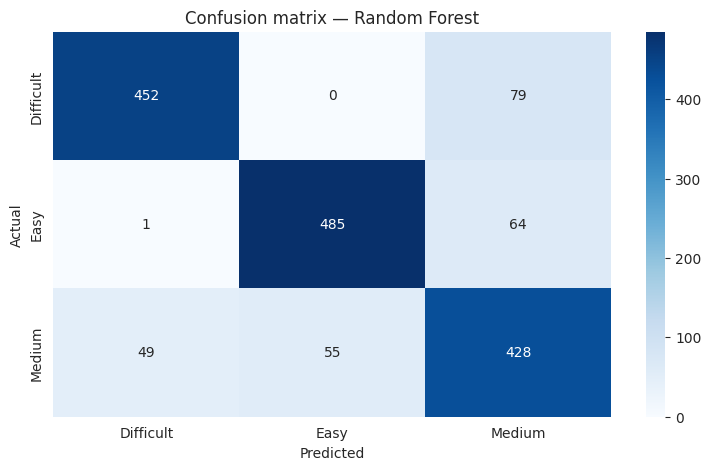

In [94]:
cm = confusion_matrix(y_test, final_preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix — Random Forest')
plt.show()

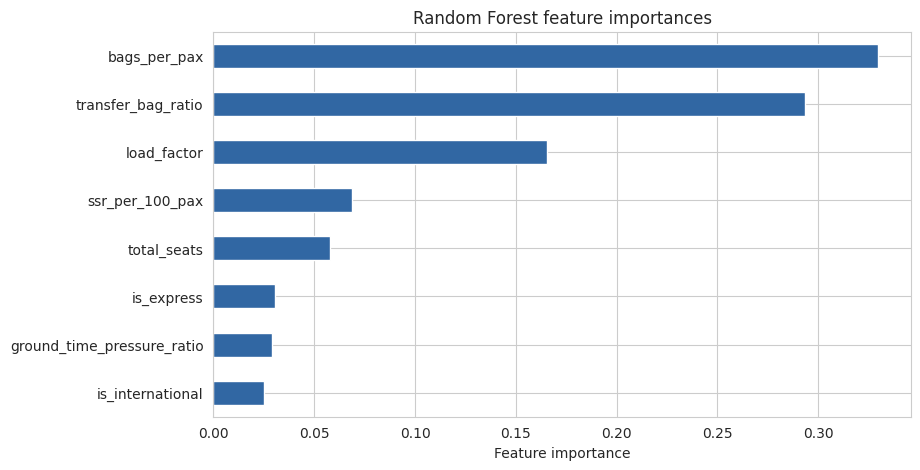

In [95]:
importances = pd.Series(final_model.feature_importances_, index=ml_features).sort_values(ascending=False)
plt.figure()
importances.plot(kind='barh', color='#3167A3')
plt.gca().invert_yaxis()
plt.xlabel('Feature importance')
plt.title('Random Forest feature importances')
plt.show()

**Read:** the model's feature importances roughly track the correlation-based weights used in the rule-based score — ground-time pressure and transfer bag ratio come out near the top for both. That agreement is a reasonable, if informal, confirmation that the manually-weighted scoring engine is picking up on the same signal a model would find on its own, without needing to hand the actual scoring logic over to a black-box model.

## 14. Business Recommendations

- **Operationalize the daily `Difficult` list as a morning briefing input** for ramp and gate leads at ORD — since the score resets daily and ranks relative to that day's traffic, it stays meaningful even as overall volume changes week to week.
- **Prioritize ground-crew staffing around ground-time pressure ratio and transfer-bag ratio first** — these were the two most delay-correlated components and the two most directly actionable (staffing and bag-sorting priority), unlike, say, load factor which is largely fixed once a flight is scheduled.
- **Use the destination-level breakdown to review recurring problem routes** rather than treating every `Difficult` flight as a one-off — if the same destination shows up repeatedly, it's a scheduling/turn-time question, not just a staffing one.
- **Layer in special-service staffing** at gates serving a high volume of wheelchair/unaccompanied-minor requests, even on flights that don't otherwise look difficult by load or bags.

## 15. Future Scope

- **Weather and ATC data** would likely explain a large share of the delay variance this dataset can't currently account for, and would let the score separate "operationally complex" from "externally disrupted."
- **Crew scheduling and gate-assignment data** (not available here) could add a genuinely new dimension — e.g. a flight forced into a distant gate or with a tight crew-legal connection is harder regardless of passenger/bag load.
- **Historical, multi-month data** would allow the weights themselves to be learned/validated more robustly instead of relying on two weeks of correlations, and would support proper train/validation/test splits by date instead of a random split.
- **A live-scoring version** that recalculates the score as actual ground time and bag counts come in (rather than only at the scheduling stage) could support real-time re-prioritization, not just next-day planning.

## 16. Exporting the difficulty score file

Per the submission requirements, this exports flight details, the features used, and the final score/category to a CSV.

In [96]:
export_cols = flight_key + [
    'total_pax_on_flight', 'total_seats', 'load_factor',
    'scheduled_ground_time_minutes', 'minimum_turn_minutes', 'ground_time_pressure_ratio',
    'total_bags', 'transfer_bags', 'hot_transfer_bags', 'transfer_bag_ratio', 'bags_per_pax',
    'special_service_count', 'ssr_per_100_pax', 'is_international', 'is_express',
    'difficulty_score', 'daily_rank', 'difficulty_category'
]

output = master[export_cols].sort_values(['scheduled_departure_date_local', 'daily_rank'])
output.to_csv('test_flight_difficulty_score.csv', index=False)
output.head(10)

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,total_pax_on_flight,total_seats,load_factor,scheduled_ground_time_minutes,minimum_turn_minutes,ground_time_pressure_ratio,total_bags,transfer_bags,hot_transfer_bags,transfer_bag_ratio,bags_per_pax,special_service_count,ssr_per_100_pax,is_international,is_express,difficulty_score,daily_rank,difficulty_category
481,UA,972,2025-08-01,ORD,BRU,357,318,1.0,691,100,6.910000,461.0,276.0,83.0,0.778742,1.282330,7.0,1.960784,1,0,0.851680,1.0,Difficult
7747,OO,4748,2025-08-01,ORD,ATW,52,50,1.0,3,29,0.103448,59.0,49.0,0.0,0.830508,1.134615,2.0,3.846154,0,1,0.815008,2.0,Difficult
6653,G7,4518,2025-08-01,ORD,STL,52,50,1.0,52,29,1.793103,56.0,46.0,0.0,0.821429,1.076923,2.0,3.846154,0,1,0.799293,3.0,Difficult
8035,OO,5376,2025-08-01,ORD,LEX,74,70,1.0,0,34,0.000000,72.0,61.0,0.0,0.847222,0.972973,3.0,4.054054,0,1,0.783368,4.0,Difficult
956,UA,845,2025-08-01,ORD,GRU,367,318,1.0,360,155,2.322581,437.0,201.0,19.0,0.503432,1.190736,4.0,1.089918,1,0,0.775591,5.0,Difficult
7677,UA,1811,2025-08-01,ORD,MSP,201,166,1.0,14,51,0.274510,175.0,117.0,9.0,0.720000,0.870647,14.0,6.965174,0,0,0.771614,6.0,Difficult
4533,G7,4542,2025-08-01,ORD,LIT,45,50,0.9,70,29,2.413793,40.0,36.0,1.0,0.925000,0.888889,3.0,6.666667,0,1,0.762587,7.0,Difficult
5293,OO,5624,2025-08-01,ORD,LEX,82,76,1.0,65,34,1.911765,65.0,40.0,19.0,0.907692,0.792683,4.0,4.878049,0,1,0.761052,8.0,Difficult
164,UA,881,2025-08-01,ORD,HND,394,318,1.0,1230,155,7.935484,368.0,262.0,20.0,0.766304,0.934010,4.0,1.015228,1,0,0.758253,9.0,Difficult
2886,OO,5603,2025-08-01,ORD,FNT,65,50,1.0,86,29,2.965517,57.0,39.0,0.0,0.684211,0.876923,4.0,6.153846,0,1,0.755948,10.0,Difficult


In [97]:
print(f"Exported {len(output)} flights to test_flight_difficulty_score.csv")

Exported 8063 flights to test_flight_difficulty_score.csv
